In [68]:
import re
import os
from tqdm import tqdm

def should_split_at_comma(text, comma_index):
    """
    Kiểm tra xem dấu phẩy có nên được sử dụng để tách câu hay không
    """
    # Kiểm tra nếu dấu phẩy nằm trong ngoặc đơn, ngoặc kép hoặc ngoặc vuông
    open_brackets = 0
    open_parentheses = 0
    open_square_brackets = 0
    in_quotes = False
    
    for i in range(comma_index):
        if text[i] == '(' and not in_quotes:
            open_parentheses += 1
        elif text[i] == ')' and not in_quotes:
            open_parentheses -= 1
        elif text[i] == '[' and not in_quotes:
            open_square_brackets += 1
        elif text[i] == ']' and not in_quotes:
            open_square_brackets -= 1
        elif text[i] == '"':
            in_quotes = not in_quotes
    
    if open_parentheses > 0 or open_square_brackets > 0 or in_quotes:
        return False
    
    # Kiểm tra nếu dấu phẩy là một phần của số thập phân
    if comma_index > 0 and comma_index < len(text) - 1:
        if text[comma_index-1].isdigit() and text[comma_index+1].isdigit():
            return False
    
    # Kiểm tra nếu dấu phẩy trong viết tắt hoặc một số trường hợp đặc biệt khác
    # Ví dụ: "Ông A, Bà B và C đã đến"
    # Nếu sau dấu phẩy là chữ cái đơn, không tách
    if comma_index < len(text) - 3:
        after_comma = text[comma_index+1:comma_index+4].strip()
        if len(after_comma) == 1 and after_comma.isalpha():
            return False
    
    return True

def split_long_sentences(input_file, output_file):
    """
    Đọc file văn bản, tách các câu dài thành các câu ngắn hơn dựa trên dấu phẩy,
    và ghi kết quả vào file output
    """
    try:
        with open(input_file, 'r', encoding='utf-8') as f:
            content = f.readlines()
        
        total_lines = len(content)
        print(f"Đang xử lý {total_lines} dòng...")
        
        result = []
        for line in tqdm(content):
            line = line.strip()
            if not line:  # Bỏ qua dòng trống
                continue
                
            # Tách câu bằng dấu chấm trước
            sentences = re.split(r'(?<!\w\.\w.)(?<![A-Z][a-z]\.)(?<=\.|\?|\!)\s', line)
            
            processed_sentences = []
            for sentence in sentences:
                sentence = sentence.strip()
                if not sentence:
                    continue
                    
                # Xác định vị trí của tất cả các dấu phẩy
                comma_positions = [m.start() for m in re.finditer(',', sentence)]
                
                if not comma_positions:
                    # Không có dấu phẩy, giữ nguyên câu
                    processed_sentences.append(sentence)
                    continue
                
                # Lọc các vị trí dấu phẩy mà ta muốn tách
                split_positions = [pos for pos in comma_positions if should_split_at_comma(sentence, pos)]
                
                if not split_positions:
                    # Không có dấu phẩy nào để tách, giữ nguyên câu
                    processed_sentences.append(sentence)
                    continue
                
                # Tách câu tại các vị trí đã xác định
                prev_pos = 0
                for pos in split_positions:
                    subclauses = sentence[prev_pos:pos].strip()
                    if subclauses:
                        processed_sentences.append(subclauses)
                    prev_pos = pos + 1
                
                # Thêm phần cuối cùng
                last_part = sentence[prev_pos:].strip()
                if last_part:
                    processed_sentences.append(last_part)
            
            result.extend(processed_sentences)
        
        # Ghi kết quả ra file
        with open(output_file, 'w', encoding='utf-8') as f:
            for sent in result:
                f.write(sent + '\n')
        
        print(f"Đã xử lý xong! Kết quả được lưu tại: {output_file}")
        print(f"Số câu đầu vào: {total_lines}")
        print(f"Số câu đầu ra: {len(result)}")
        
    except Exception as e:
        print(f"Có lỗi xảy ra: {str(e)}")

def process_file():
    """
    Hàm chính để xử lý file
    """
    input_file = "raw_data/sentences_50000.txt"
    output_file = "raw_data/full_raw_data_tach_cau.txt"
    
    if not os.path.exists(input_file):
        print(f"File {input_file} không tồn tại!")
        return
    
    split_long_sentences(input_file, output_file)


In [69]:
process_file()

Đang xử lý 50000 dòng...


100%|██████████| 50000/50000 [00:01<00:00, 34000.67it/s]


Đã xử lý xong! Kết quả được lưu tại: raw_data/full_raw_data_tach_cau.txt
Số câu đầu vào: 50000
Số câu đầu ra: 116854


In [70]:
import re
import os
from tqdm import tqdm

def contains_special_chars(text):
    """
    Kiểm tra xem chuỗi có chứa ký tự đặc biệt ngoài chữ, số, dấu phẩy và dấu chấm hay không
    """
    # Mẫu regex để tìm các ký tự đặc biệt ngoài chữ, số, dấu phẩy, dấu chấm và khoảng trắng
    # Bao gồm tất cả các ký tự tiếng Việt có dấu
    pattern = r'[^\w\s.,àáảãạăắằẳẵặâấầẩẫậèéẻẽẹêếềểễệìíỉĩịòóỏõọôốồổỗộơớờởỡợùúủũụưứừửữựỳýỷỹỵđÀÁẢÃẠĂẮẰẲẴẶÂẤẦẨẪẬÈÉẺẼẸÊẾỀỂỄỆÌÍỈĨỊÒÓỎÕỌÔỐỒỔỖỘƠỚỜỞỠỢÙÚỦŨỤƯỨỪỬỮỰỲÝỶỸỴĐ]'
    
    # Tìm kiếm ký tự đặc biệt
    special_chars = re.findall(pattern, text)
    return len(special_chars) > 0

def filter_sentences(input_file, output_file):
    """
    Đọc file văn bản đã tách câu, loại bỏ các câu chứa ký tự đặc biệt
    """
    try:
        # Đọc file đầu vào
        with open(input_file, 'r', encoding='utf-8') as f:
            sentences = f.readlines()
        
        total_sentences = len(sentences)
        print(f"Đang xử lý {total_sentences} câu...")
        
        # Lọc các câu không chứa ký tự đặc biệt
        filtered_sentences = []
        removed_count = 0
        
        for sentence in tqdm(sentences):
            sentence = sentence.strip()
            if not sentence:  # Bỏ qua dòng trống
                continue
            
            # Kiểm tra nếu câu chứa ký tự đặc biệt
            if contains_special_chars(sentence):
                removed_count += 1
                continue
            
            # Thêm câu vào danh sách kết quả
            filtered_sentences.append(sentence)
        
        # Ghi kết quả ra file
        with open(output_file, 'w', encoding='utf-8') as f:
            for sent in filtered_sentences:
                f.write(sent + '\n')
        
        print(f"Đã xử lý xong! Kết quả được lưu tại: {output_file}")
        print(f"Số câu đầu vào: {total_sentences}")
        print(f"Số câu bị loại bỏ vì chứa ký tự đặc biệt: {removed_count}")
        print(f"Số câu đầu ra: {len(filtered_sentences)}")
        
    except Exception as e:
        print(f"Có lỗi xảy ra: {str(e)}")

def process_file():
    """
    Hàm chính để xử lý file
    """
    input_file = "raw_data/full_raw_data_tach_cau.txt"
    output_file = "raw_data/full_raw_data_loai_ky_tu_dac_biet.txt"
    
    if not os.path.exists(input_file):
        print(f"File {input_file} không tồn tại!")
        return
    
    filter_sentences(input_file, output_file)


In [71]:
process_file()

Đang xử lý 116854 câu...


100%|██████████| 116854/116854 [00:00<00:00, 545128.48it/s]

Đã xử lý xong! Kết quả được lưu tại: raw_data/full_raw_data_loai_ky_tu_dac_biet.txt
Số câu đầu vào: 116854
Số câu bị loại bỏ vì chứa ký tự đặc biệt: 26243
Số câu đầu ra: 90611


In [72]:
import re
import os
from tqdm import tqdm

def has_consecutive_digits(text):
    """
    Kiểm tra xem chuỗi có chứa 2 chữ số liền kề trở lên hay không
    """
    # Tìm các chuỗi chứa ít nhất 2 chữ số liền kề
    pattern = r'\d{2,}'
    match = re.search(pattern, text)
    return match is not None

def clean_and_filter_sentences(input_file, output_file):
    """
    Đọc file văn bản, loại bỏ dấu chấm và dấu phẩy, 
    loại bỏ câu chứa 2 chữ số liền kề trở lên
    """
    try:
        # Đọc file đầu vào
        with open(input_file, 'r', encoding='utf-8') as f:
            sentences = f.readlines()
        
        total_sentences = len(sentences)
        print(f"Đang xử lý {total_sentences} câu...")
        
        # Lọc và làm sạch các câu
        cleaned_sentences = []
        removed_digits_count = 0
        
        for sentence in tqdm(sentences):
            sentence = sentence.strip()
            if not sentence:  # Bỏ qua dòng trống
                continue
            
            # Kiểm tra nếu câu chứa 2 chữ số liền kề trở lên
            if has_consecutive_digits(sentence):
                removed_digits_count += 1
                continue
            
            # Loại bỏ dấu chấm và dấu phẩy
            cleaned_sentence = sentence.replace('.', '').replace(',', '')
            
            # Thêm câu đã làm sạch vào danh sách kết quả
            cleaned_sentences.append(cleaned_sentence)
        
        # Ghi kết quả ra file
        with open(output_file, 'w', encoding='utf-8') as f:
            for sent in cleaned_sentences:
                f.write(sent + '\n')
        
        print(f"Đã xử lý xong! Kết quả được lưu tại: {output_file}")
        print(f"Số câu đầu vào: {total_sentences}")
        print(f"Số câu bị loại bỏ vì chứa 2+ chữ số liền kề: {removed_digits_count}")
        print(f"Số câu đầu ra: {len(cleaned_sentences)}")
        
    except Exception as e:
        print(f"Có lỗi xảy ra: {str(e)}")

def process_file():
    """
    Hàm chính để xử lý file
    """
    input_file = "raw_data/full_raw_data_loai_ky_tu_dac_biet.txt"
    output_file = "raw_data/full_raw_data_loai_so.txt"
    
    if not os.path.exists(input_file):
        print(f"File {input_file} không tồn tại!")
        return
    
    clean_and_filter_sentences(input_file, output_file)


In [73]:
process_file()

Đang xử lý 90611 câu...


100%|██████████| 90611/90611 [00:00<00:00, 532921.19it/s]


Đã xử lý xong! Kết quả được lưu tại: raw_data/full_raw_data_loai_so.txt
Số câu đầu vào: 90611
Số câu bị loại bỏ vì chứa 2+ chữ số liền kề: 8112
Số câu đầu ra: 82499


In [74]:
import re
import os
import matplotlib.pyplot as plt
from collections import Counter
from tqdm import tqdm
import numpy as np

def number_to_vietnamese_word(number):
    """
    Chuyển đổi số đơn lẻ sang chữ tiếng Việt
    """
    vietnamese_numbers = {
        '0': 'không',
        '1': 'một',
        '2': 'hai',
        '3': 'ba',
        '4': 'bốn',
        '5': 'năm',
        '6': 'sáu',
        '7': 'bảy',
        '8': 'tám',
        '9': 'chín'
    }
    
    return vietnamese_numbers.get(number, number)

def convert_single_digits(text):
    """
    Chuyển đổi các chữ số đơn lẻ trong văn bản sang từ tiếng Việt
    """
    # Tìm và thay thế các chữ số đơn lẻ, không phải là một phần của số lớn hơn
    # Chỉ xử lý khi chữ số đứng một mình (không kề với chữ số khác)
    pattern = r'(?<!\d)(\d)(?!\d)'
    return re.sub(pattern, lambda m: number_to_vietnamese_word(m.group(1)), text)

def normalize_text(input_file, output_file):
    """
    Chuẩn hóa văn bản: chuyển chữ hoa thành chữ thường, chuyển số đơn lẻ thành chữ
    """
    try:
        # Đọc file đầu vào
        with open(input_file, 'r', encoding='utf-8') as f:
            sentences = f.readlines()
        
        total_sentences = len(sentences)
        print(f"Đang xử lý {total_sentences} câu...")
        
        # Chuẩn hóa các câu
        normalized_sentences = []
        
        for sentence in tqdm(sentences):
            sentence = sentence.strip().lower()
            if not sentence:  # Bỏ qua dòng trống
                continue
            
            # Chuyển các số đơn lẻ thành chữ
            normalized_sentence = convert_single_digits(sentence)
            
            # Thêm câu đã chuẩn hóa vào danh sách
            normalized_sentences.append(normalized_sentence)
        
        # Ghi kết quả ra file
        with open(output_file, 'w', encoding='utf-8') as f:
            for sent in normalized_sentences:
                f.write(sent + '\n')
        
        print(f"Đã chuẩn hóa xong! Kết quả được lưu tại: {output_file}")
        print(f"Số câu đã xử lý: {len(normalized_sentences)}")
        
        return normalized_sentences
        
    except Exception as e:
        print(f"Có lỗi xảy ra: {str(e)}")
        return []

def build_vocabulary(sentences):
    """
    Xây dựng từ điển vocab từ danh sách câu
    """
    vocabulary = Counter()
    
    # Phân tách mỗi câu thành các từ và đếm tần suất
    for sentence in tqdm(sentences, desc="Đang xây dựng vocab"):
        words = sentence.split()
        vocabulary.update(words)
    
    print(f"Đã xây dựng vocab với {len(vocabulary)} từ khác nhau")
    return vocabulary

def plot_least_frequent_words(vocabulary, n=30):
    """
    Vẽ biểu đồ n từ có tần suất xuất hiện ít nhất
    """
    # Lấy n từ có tần suất xuất hiện ít nhất
    least_common = vocabulary.most_common()[:-n-1:-1]
    
    # Chuẩn bị dữ liệu cho biểu đồ
    words = [word for word, count in least_common]
    counts = [count for word, count in least_common]
    
    # Vẽ biểu đồ
    plt.figure(figsize=(15, 10))
    
    # Sử dụng horizontal bar chart để hiển thị rõ các từ
    bars = plt.barh(words, counts, color='skyblue')
    
    # Thêm số liệu trên các cột
    for bar in bars:
        width = bar.get_width()
        plt.text(width + 0.1, bar.get_y() + bar.get_height()/2, f'{width:.0f}', 
                ha='left', va='center', fontsize=10)
    
    plt.title(f'{n} từ có tần suất xuất hiện ít nhất', fontsize=16)
    plt.xlabel('Tần suất xuất hiện', fontsize=12)
    plt.ylabel('Từ', fontsize=12)
    plt.tight_layout()
    
    # Lưu biểu đồ
    plt.savefig('least_frequent_words.png')
    print(f"Đã lưu biểu đồ {n} từ có tần suất xuất hiện ít nhất vào 'least_frequent_words.png'")
    
    # Hiển thị biểu đồ nếu chạy trên môi trường tương tác
    plt.show()

def filter_vocabulary(vocabulary, sentences, min_count, output_file):
    """
    Lọc từ điển vocab và loại bỏ những câu chứa từ xuất hiện ít hơn min_count lần
    
    Args:
        vocabulary (Counter): Từ điển tần suất các từ
        sentences (list): Danh sách các câu cần lọc
        min_count (int): Ngưỡng tần suất tối thiểu
        output_file (str): Đường dẫn file đầu ra
        
    Returns:
        tuple: (filtered_vocab, filtered_sentences) - từ điển đã lọc và danh sách câu đã lọc
    """
    # Lọc từ điển
    filtered_vocab = {word: count for word, count in vocabulary.items() if count >= min_count}
    
    # Lọc các câu, loại bỏ hoàn toàn câu chứa từ có tần suất thấp
    filtered_sentences = []
    
    for sentence in tqdm(sentences, desc="Đang lọc câu"):
        words = sentence.split()
        
        # Kiểm tra xem câu có chứa từ nào không nằm trong filtered_vocab không
        contains_rare_word = any(word not in filtered_vocab for word in words)
        
        # Chỉ giữ lại những câu không chứa từ hiếm
        if not contains_rare_word and words:
            filtered_sentences.append(sentence)
    
    # Ghi kết quả ra file
    with open(output_file, 'w', encoding='utf-8') as f:
        for sent in filtered_sentences:
            f.write(sent + '\n')
    
    print(f"Đã lọc xong! Kết quả được lưu tại: {output_file}")
    print(f"Số từ ban đầu: {len(vocabulary)}")
    print(f"Số từ sau khi lọc: {len(filtered_vocab)}")
    print(f"Số câu ban đầu: {len(sentences)}")
    print(f"Số câu sau khi lọc: {len(filtered_sentences)}")
    print(f"Đã loại bỏ {len(sentences) - len(filtered_sentences)} câu chứa từ hiếm")
    
    return filtered_vocab, filtered_sentences

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_frequency_distribution(vocabulary, max_freq=50, log_scale=False):
    """
    Vẽ biểu đồ phân bố tần suất từ trong vocab.
    
    Parameters:
    - vocabulary: Counter object (từ điển từ và tần suất)
    - max_freq: Giới hạn trục x để biểu đồ dễ nhìn (VD: 50 lần xuất hiện trở xuống)
    - log_scale: Có dùng thang log cho trục y không
    """
    # Lấy danh sách tần suất xuất hiện
    frequencies = list(vocabulary.values())
    
    # Giới hạn để tránh nhiễu (ví dụ: chỉ vẽ những từ xuất hiện <= max_freq)
    filtered_freqs = [f for f in frequencies if f <= max_freq]

    # Vẽ histogram
    plt.figure(figsize=(12, 6))
    sns.histplot(filtered_freqs, bins=max_freq, kde=False, color='skyblue')
    
    plt.title(f'Phân bố tần suất từ (tối đa {max_freq} lần xuất hiện)', fontsize=14)
    plt.xlabel('Số lần xuất hiện của từ', fontsize=12)
    plt.ylabel('Số lượng từ', fontsize=12)
    
    if log_scale:
        plt.yscale('log')  # Dùng thang log để trực quan hóa rõ hơn
    
    plt.tight_layout()
    plt.savefig('frequency_distribution.png')
    print("Đã lưu biểu đồ phân bố tần suất từ vào 'frequency_distribution.png'")
    plt.show()


In [76]:
import matplotlib.pyplot as plt

def plot_full_frequency_distribution(vocabulary, log_scale=True):
    """
    Vẽ biểu đồ tần suất tất cả các từ, sắp xếp theo thứ tự giảm dần (Zipf's Law).
    
    Parameters:
    - vocabulary: Counter object chứa từ và tần suất
    - log_scale: nếu True, dùng log-log scale (theo Zipf)
    """
    # Sắp xếp từ theo tần suất giảm dần
    sorted_counts = sorted(vocabulary.values(), reverse=True)
    
    # Tạo x-axis là thứ hạng của từ (1, 2, 3, ..., N)
    ranks = range(1, len(sorted_counts) + 1)
    
    plt.figure(figsize=(12, 6))
    plt.plot(ranks, sorted_counts, color='blue')
    
    if log_scale:
        plt.xscale('log')
        plt.yscale('log')
        plt.title('Biểu đồ Zipf (log-log) của tần suất từ', fontsize=14)
    else:
        plt.title('Biểu đồ tần suất từ theo thứ tự giảm dần', fontsize=14)
    
    plt.xlabel('Thứ hạng của từ (từ phổ biến nhất đến ít nhất)', fontsize=12)
    plt.ylabel('Tần suất xuất hiện', fontsize=12)
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.tight_layout()
    
    plt.savefig('zipf_full_distribution.png')
    print("Đã lưu biểu đồ phân bố tần suất đầy đủ vào 'zipf_full_distribution.png'")
    plt.show()


In [77]:
def plot_top_frequent_words(vocabulary, n=30):
    """
    Vẽ biểu đồ top n từ có tần suất xuất hiện cao nhất.
    """
    # Lấy n từ phổ biến nhất
    most_common = vocabulary.most_common(n)
    
    # Chuẩn bị dữ liệu
    words = [word for word, count in most_common]
    counts = [count for word, count in most_common]
    
    # Vẽ biểu đồ
    plt.figure(figsize=(15, 8))
    bars = plt.bar(words, counts, color='skyblue')
    
    # Thêm giá trị lên từng cột, xoay để không bị chồng
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2, height + max(counts) * 0.01,
                 f'{height:,}', ha='center', va='bottom', fontsize=10, rotation=45)
    
    plt.title(f'Top {n} từ xuất hiện nhiều nhất', fontsize=16)
    plt.xlabel('Từ', fontsize=12)
    plt.ylabel('Tần suất xuất hiện', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    
    # Lưu biểu đồ
    plt.savefig('top_frequent_words.png')
    print(f"Đã lưu biểu đồ top {n} từ phổ biến vào 'top_frequent_words.png'")
    
    # Hiển thị biểu đồ
    plt.show()


In [78]:
input_file = "raw_data/full_raw_data_loai_so.txt"
normalized_output = "raw_data/full_raw_data_chuan_hoa.txt"

normalized_sentences = normalize_text(input_file, normalized_output)

# Bước 2: Xây dựng từ điển vocab
vocabulary = build_vocabulary(normalized_sentences)


Đang xử lý 82499 câu...


100%|██████████| 82499/82499 [00:00<00:00, 332118.11it/s]


Đã chuẩn hóa xong! Kết quả được lưu tại: raw_data/full_raw_data_chuan_hoa.txt
Số câu đã xử lý: 82428


Đang xây dựng vocab: 100%|██████████| 82428/82428 [00:00<00:00, 372039.87it/s]

Đã xây dựng vocab với 9853 từ khác nhau


Đã lưu biểu đồ 30 từ có tần suất xuất hiện ít nhất vào 'least_frequent_words.png'


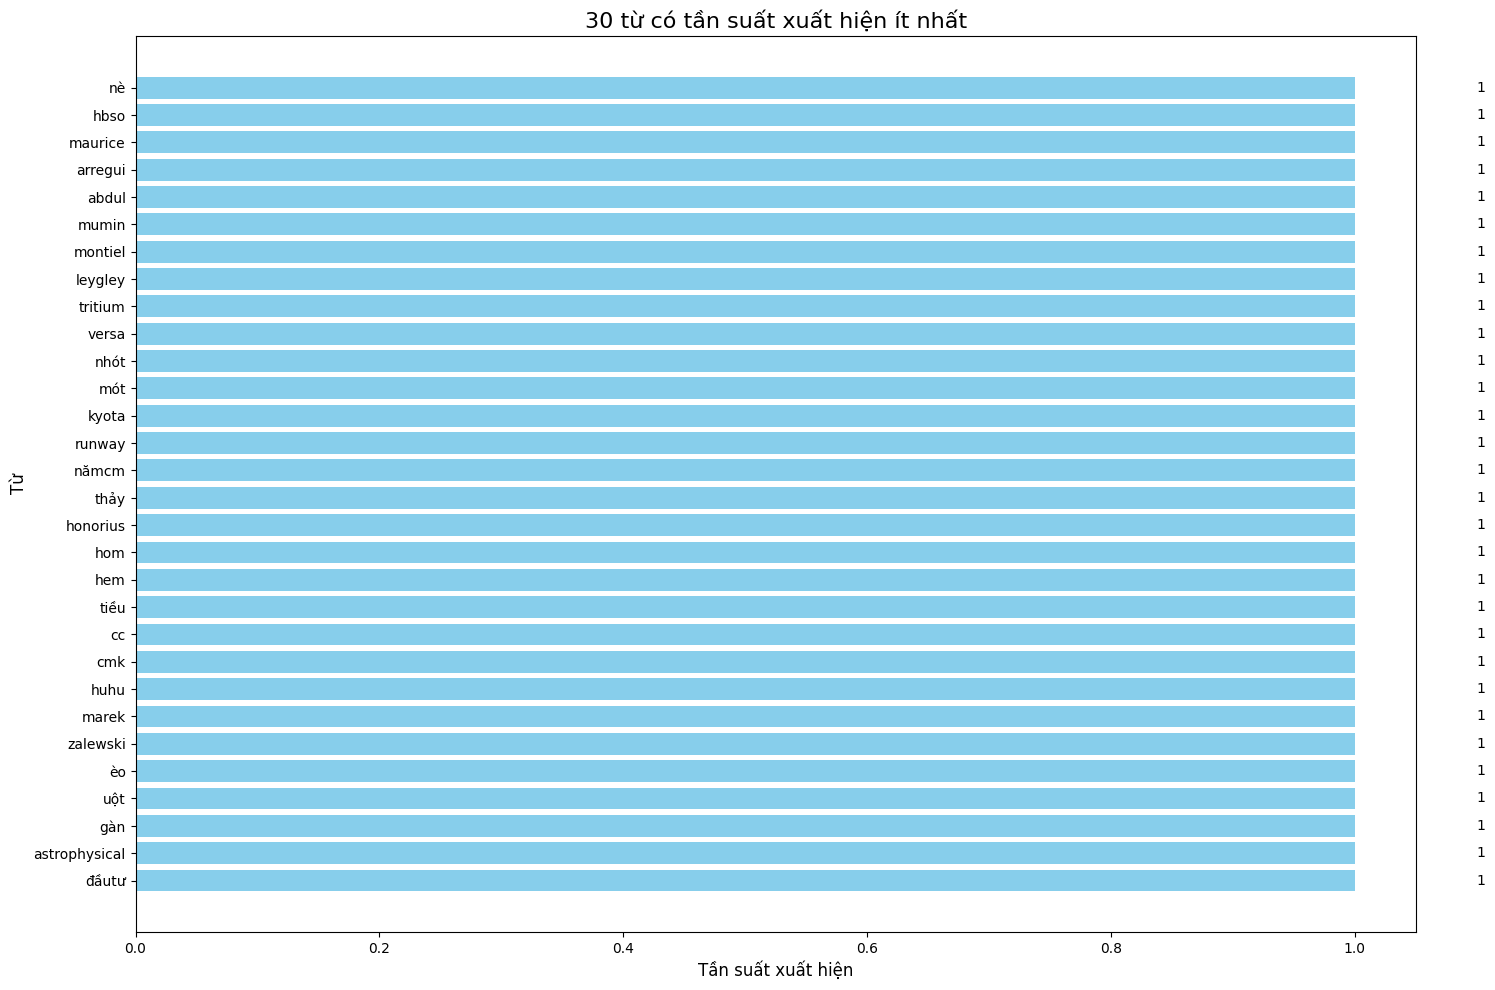

In [79]:
# Bước 3: Vẽ biểu đồ 30 từ có tần suất xuất hiện ít nhất
plot_least_frequent_words(vocabulary, 30)

Đã lưu biểu đồ 50 từ có tần suất xuất hiện ít nhất vào 'least_frequent_words.png'


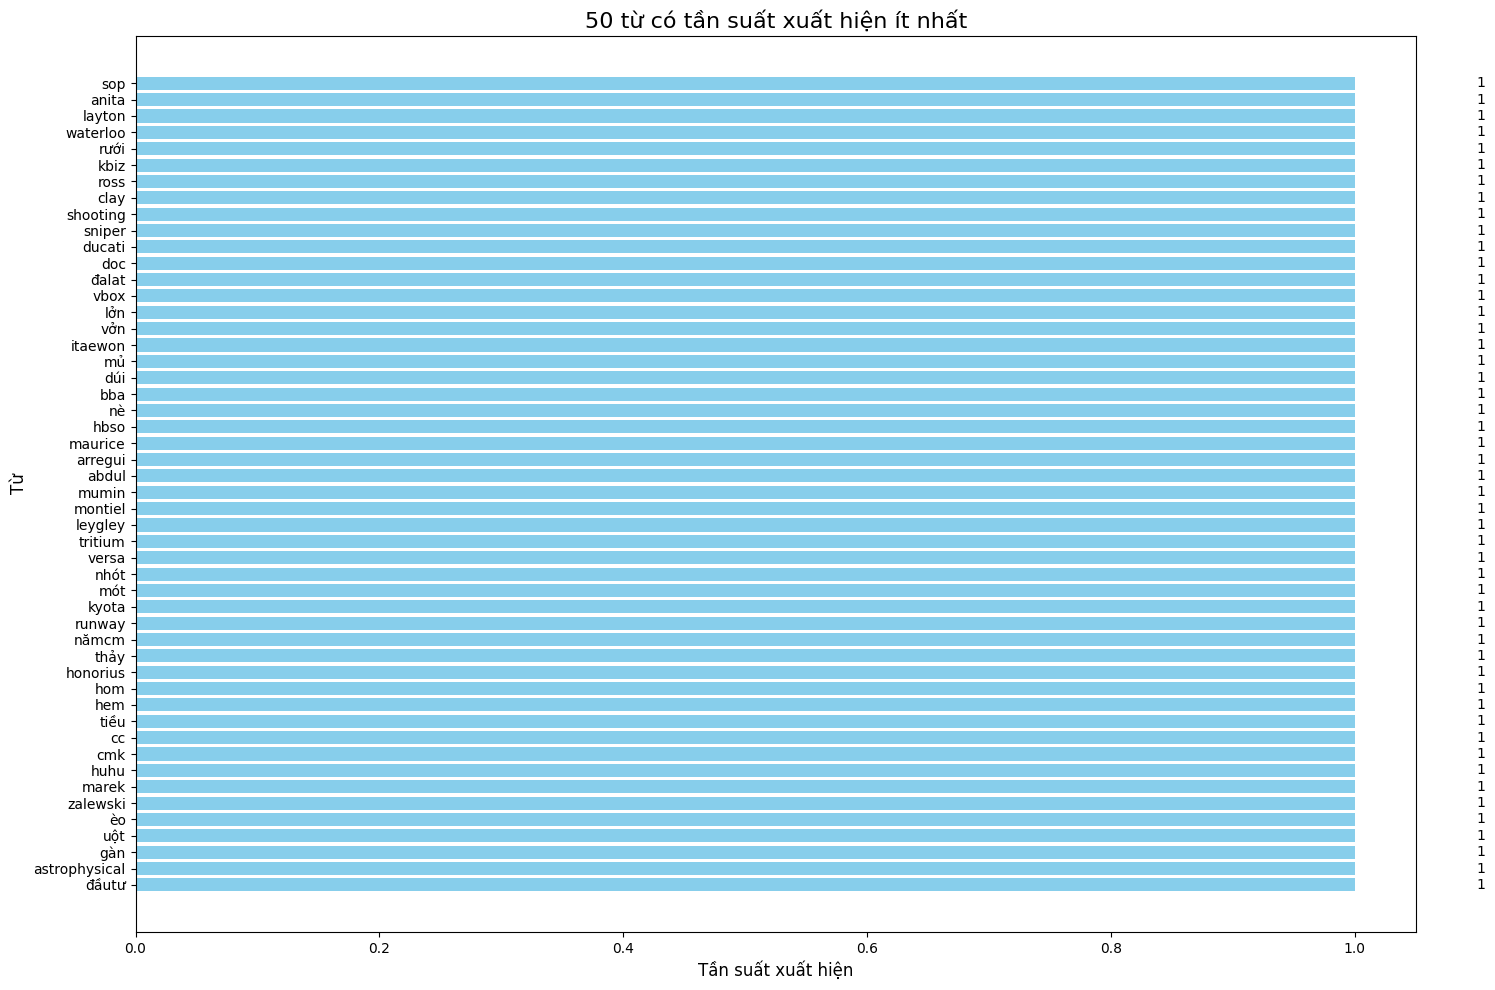

In [80]:
# Bước 3: Vẽ biểu đồ 50 từ có tần suất xuất hiện ít nhất
plot_least_frequent_words(vocabulary, 50)

Đã lưu biểu đồ phân bố tần suất từ vào 'frequency_distribution.png'


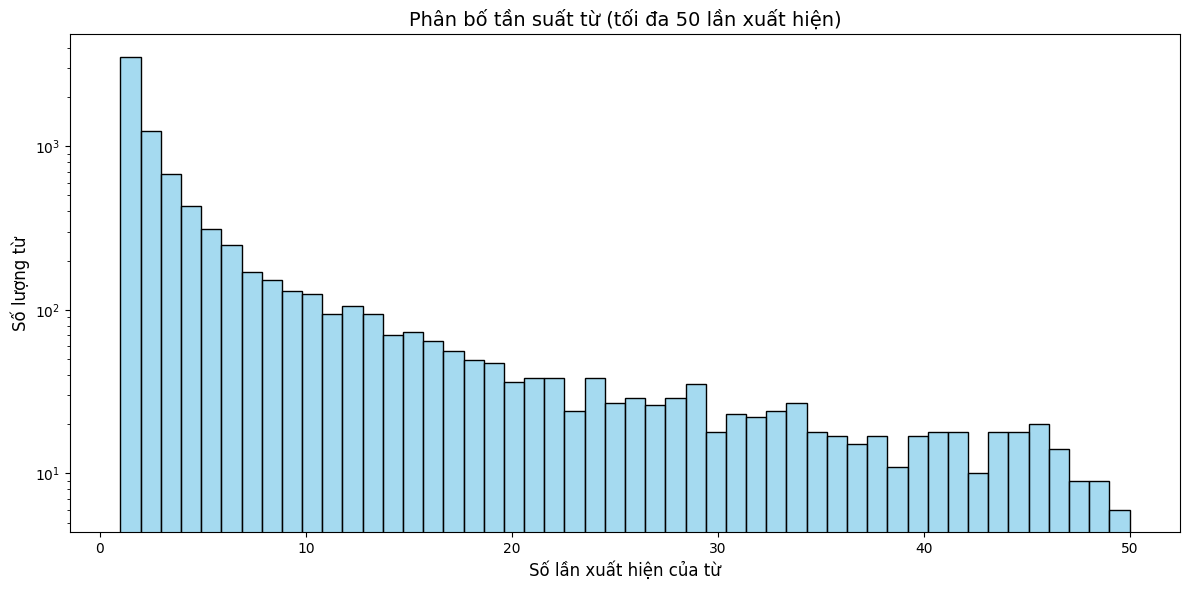

In [81]:
plot_frequency_distribution(vocabulary, max_freq=50, log_scale=True)

Đã lưu biểu đồ phân bố tần suất đầy đủ vào 'zipf_full_distribution.png'


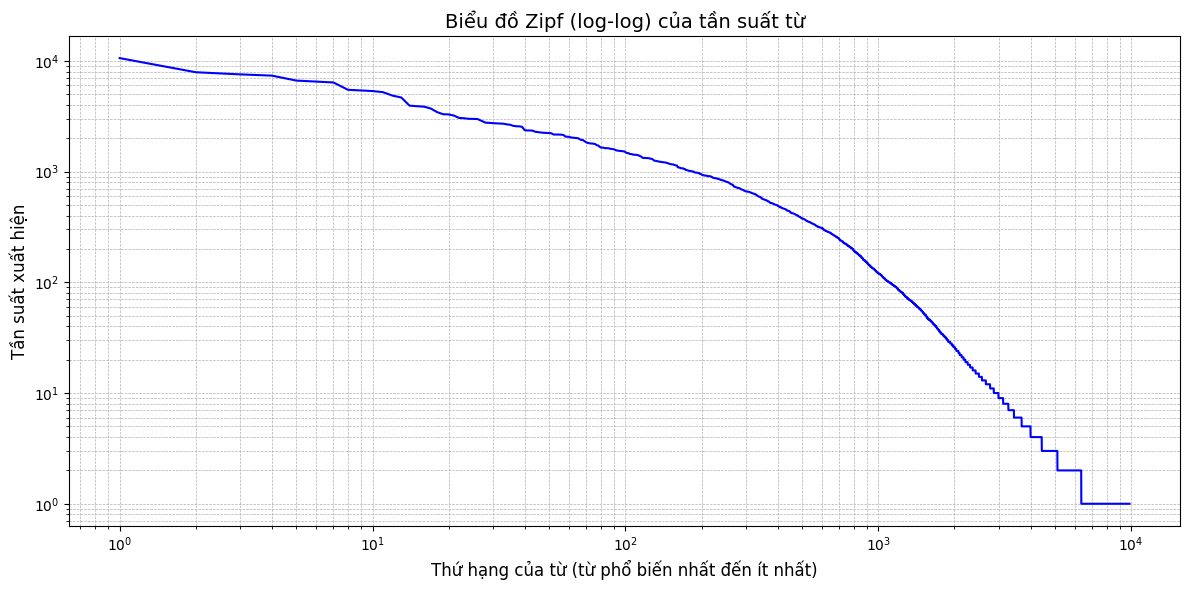

In [82]:
plot_full_frequency_distribution(vocabulary, log_scale=True)

Đã lưu biểu đồ top 50 từ phổ biến vào 'top_frequent_words.png'


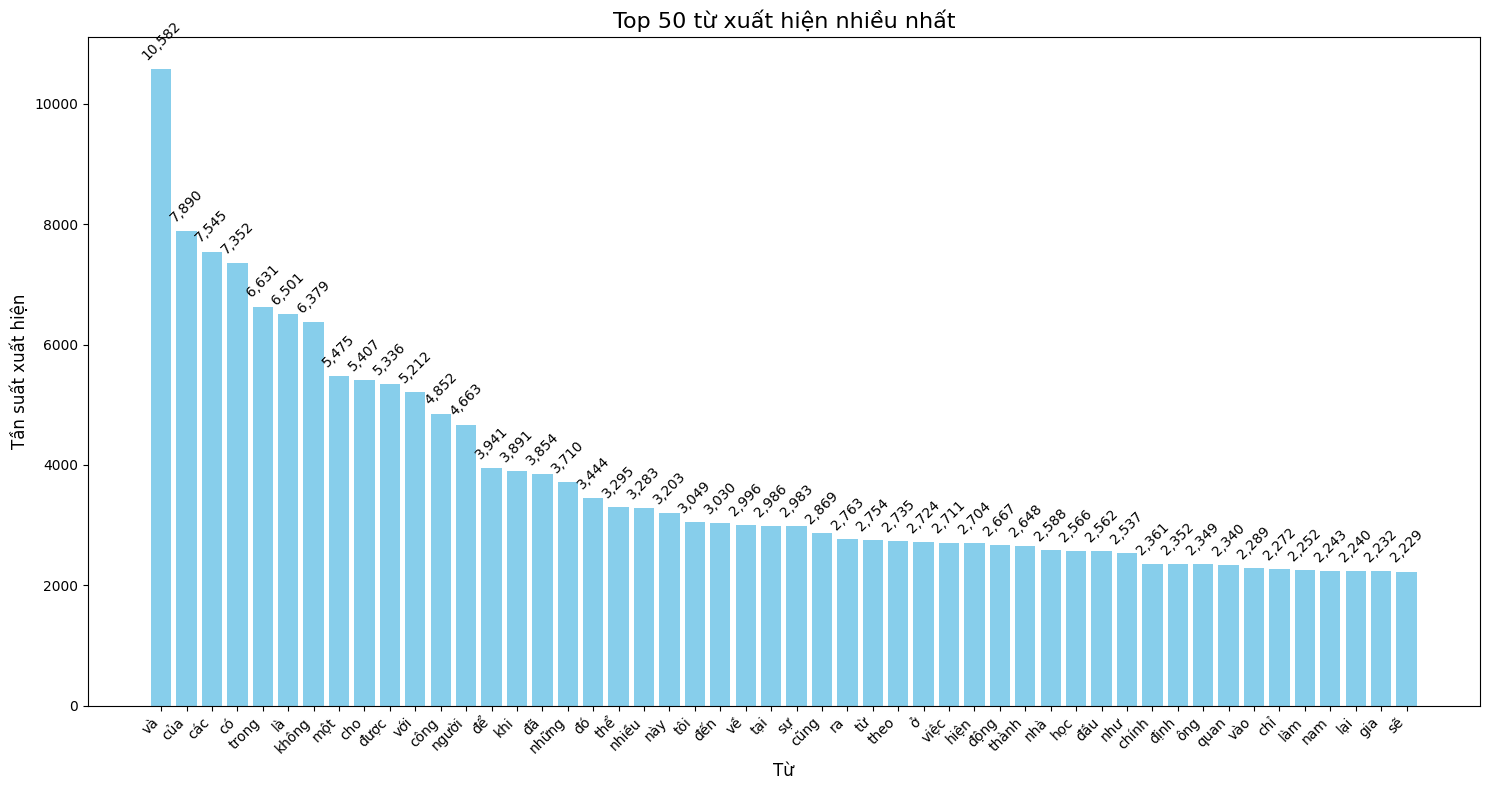

In [83]:
plot_top_frequent_words(vocabulary, n=50)

In [84]:
min_count = 30
filtered_output = "raw_data/full_raw_data_loai_nhung_cau_chua_tu_co_tan_suat_nho_hon_30.txt"
filtered_vocab, filtered_sentences = filter_vocabulary(vocabulary, normalized_sentences, min_count, filtered_output)

print("Hoàn thành tất cả các bước xử lý!")

Đang lọc câu: 100%|██████████| 82428/82428 [00:00<00:00, 380571.71it/s]

Đã lọc xong! Kết quả được lưu tại: raw_data/full_raw_data_loai_nhung_cau_chua_tu_co_tan_suat_nho_hon_30.txt
Số từ ban đầu: 9853
Số từ sau khi lọc: 1889
Số câu ban đầu: 82428
Số câu sau khi lọc: 59494
Đã loại bỏ 22934 câu chứa từ hiếm
Hoàn thành tất cả các bước xử lý!


In [85]:
filtered_vocab = build_vocabulary(filtered_sentences)

Đang xây dựng vocab: 100%|██████████| 59494/59494 [00:00<00:00, 392027.24it/s]

Đã xây dựng vocab với 1886 từ khác nhau


Đã lưu biểu đồ 30 từ có tần suất xuất hiện ít nhất vào 'least_frequent_words.png'


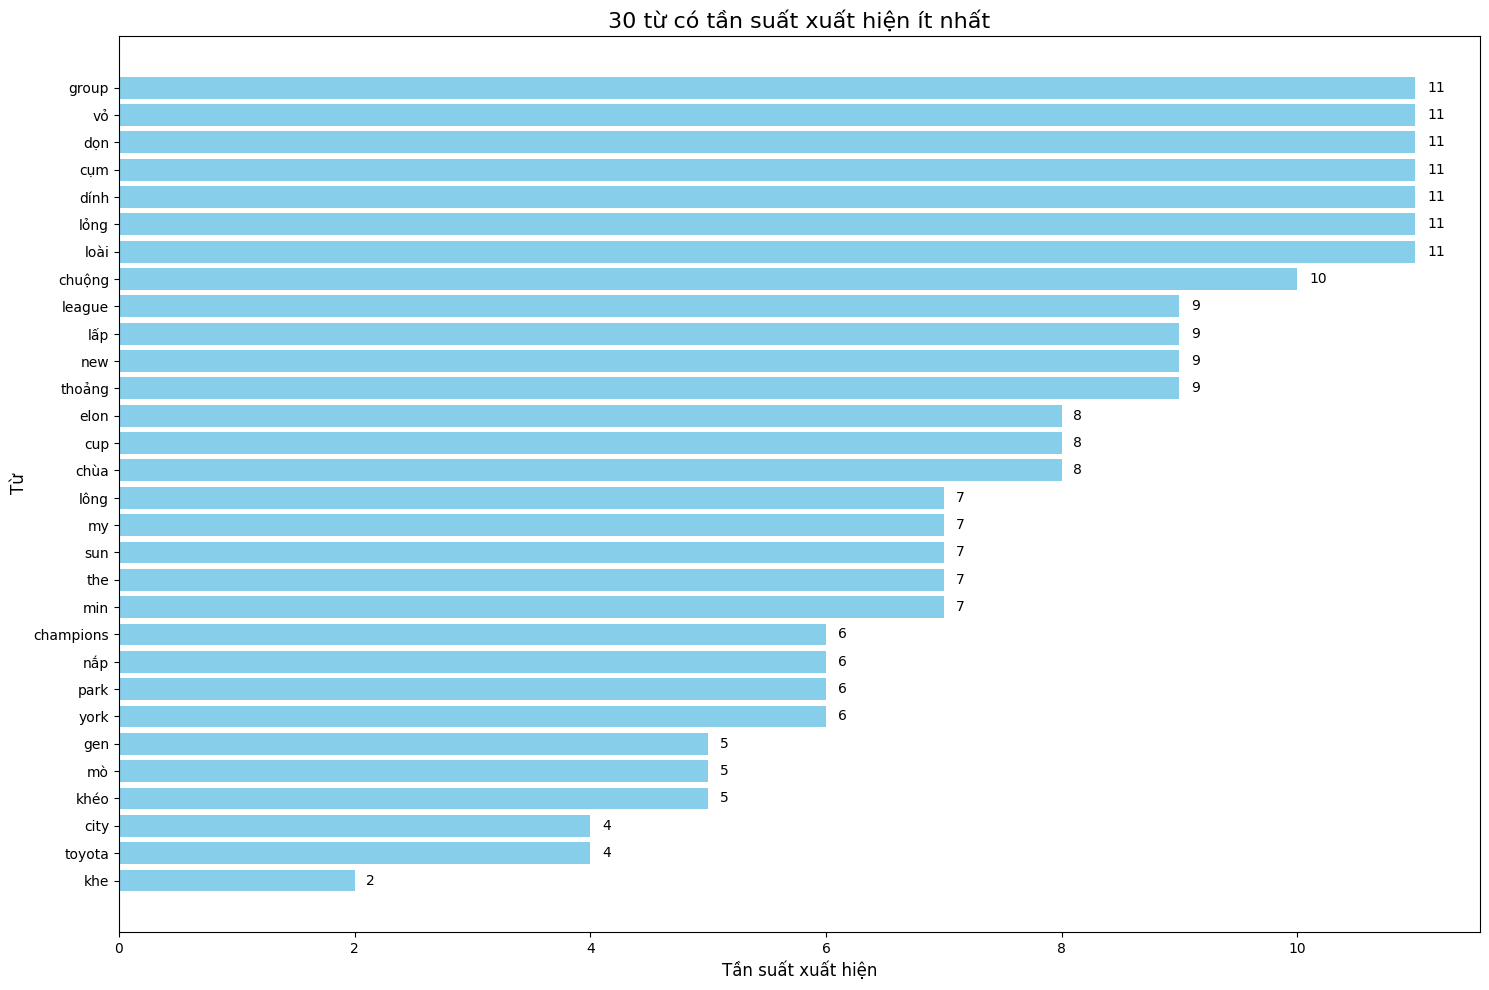

In [86]:
plot_least_frequent_words(filtered_vocab, 30)

In [87]:
import random

def split_large_txt(input_path, train_path, val_path, train_ratio=0.8):
    with open(input_path, 'r', encoding='utf-8') as f:
        lines = [line.rstrip() for line in f if line.strip()]
    
    total = len(lines)
    print(f"Tổng số dòng: {total}")

    random.shuffle(lines)

    train_size = int(total * train_ratio)

    with open(train_path, 'w', encoding='utf-8') as f:
        f.write('\n'.join(lines[:train_size]) + '\n')

    with open(val_path, 'w', encoding='utf-8') as f:
        f.write('\n'.join(lines[train_size:]) + '\n')

    print(f"Đã ghi {train_size} dòng vào '{train_path}' và {total - train_size} dòng vào '{val_path}'.")


In [88]:
split_large_txt('raw_data/full_raw_data_loai_nhung_cau_chua_tu_co_tan_suat_nho_hon_30.txt', 'dataset/train/label.txt', 'dataset/val/label.txt')

Tổng số dòng: 59494
Đã ghi 47595 dòng vào 'dataset/train/label.txt' và 11899 dòng vào 'dataset/val/label.txt'.


In [91]:
def remove_vietnamese_accents(text):
    accent_map = {
        'à': 'a', 'á': 'a', 'ả': 'a', 'ã': 'a', 'ạ': 'a',
        'ă': 'a', 'ằ': 'a', 'ắ': 'a', 'ẳ': 'a', 'ẵ': 'a', 'ặ': 'a',
        'â': 'a', 'ầ': 'a', 'ấ': 'a', 'ẩ': 'a', 'ẫ': 'a', 'ậ': 'a',
        'đ': 'd',
        'è': 'e', 'é': 'e', 'ẻ': 'e', 'ẽ': 'e', 'ẹ': 'e',
        'ê': 'e', 'ề': 'e', 'ế': 'e', 'ể': 'e', 'ễ': 'e', 'ệ': 'e',
        'ì': 'i', 'í': 'i', 'ỉ': 'i', 'ĩ': 'i', 'ị': 'i',
        'ò': 'o', 'ó': 'o', 'ỏ': 'o', 'õ': 'o', 'ọ': 'o',
        'ô': 'o', 'ồ': 'o', 'ố': 'o', 'ổ': 'o', 'ỗ': 'o', 'ộ': 'o',
        'ơ': 'o', 'ờ': 'o', 'ớ': 'o', 'ở': 'o', 'ỡ': 'o', 'ợ': 'o',
        'ù': 'u', 'ú': 'u', 'ủ': 'u', 'ũ': 'u', 'ụ': 'u',
        'ư': 'u', 'ừ': 'u', 'ứ': 'u', 'ử': 'u', 'ữ': 'u', 'ự': 'u',
        'ỳ': 'y', 'ý': 'y', 'ỷ': 'y', 'ỹ': 'y', 'ỵ': 'y',
        'À': 'A', 'Á': 'A', 'Ả': 'A', 'Ã': 'A', 'Ạ': 'A',
        'Ă': 'A', 'Ằ': 'A', 'Ắ': 'A', 'Ẳ': 'A', 'Ẵ': 'A', 'Ặ': 'A',
        'Â': 'A', 'Ầ': 'A', 'Ấ': 'A', 'Ẩ': 'A', 'Ẫ': 'A', 'Ậ': 'A',
        'Đ': 'D',
        'È': 'E', 'É': 'E', 'Ẻ': 'E', 'Ẽ': 'E', 'Ẹ': 'E',
        'Ê': 'E', 'Ề': 'E', 'Ế': 'E', 'Ể': 'E', 'Ễ': 'E', 'Ệ': 'E',
        'Ì': 'I', 'Í': 'I', 'Ỉ': 'I', 'Ĩ': 'I', 'Ị': 'I',
        'Ò': 'O', 'Ó': 'O', 'Ỏ': 'O', 'Õ': 'O', 'Ọ': 'O',
        'Ô': 'O', 'Ồ': 'O', 'Ố': 'O', 'Ổ': 'O', 'Ỗ': 'O', 'Ộ': 'O',
        'Ơ': 'O', 'Ờ': 'O', 'Ớ': 'O', 'Ở': 'O', 'Ỡ': 'O', 'Ợ': 'O',
        'Ù': 'U', 'Ú': 'U', 'Ủ': 'U', 'Ũ': 'U', 'Ụ': 'U',
        'Ư': 'U', 'Ừ': 'U', 'Ứ': 'U', 'Ử': 'U', 'Ữ': 'U', 'Ự': 'U',
        'Ỳ': 'Y', 'Ý': 'Y', 'Ỷ': 'Y', 'Ỹ': 'Y', 'Ỵ': 'Y'
    }
    
    result = ""
    for index, char in enumerate(text):
        result += accent_map.get(char, char)
    
    return result

input_file = "dataset/train/label.txt"
output_file = "dataset/train/cau_khong_dau.txt"

with open(input_file, "r", encoding="utf-8") as f_in, \
     open(output_file, "w", encoding="utf-8") as f_out:

    for line in f_in:
        new_line = remove_vietnamese_accents(line)
        f_out.write(new_line)